# Post-processing chain

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.starquery  as sq
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

 "IMPORTANT: The GACS archive will be down from April 18, 2024, 16:30 CEST until April 23, 2024, 08:30 CEST."


In [3]:
# Define paths used throughout
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'

---
## Test poly-detrend model comparison
---

In [103]:
path = '/lhome/nicholas/software/workdir/mocka_affogato'
filename = f'{path}/test_hdf5/output/000000001/000000001_Ncam1.1_Q1.hdf5'
# filename = f'{path}/test_local/000000005/000000005_Ncam4.1_Q3.hdf5'

lc = LightCurve(filename)

In [101]:
# Data
df = lc.data()
df = df.loc[:int(30*86400/25)]
df = df.rename(columns={'time':'x', 'flux':'y'})

# Test models
model1 = 'y ~ x'
model2 = 'y ~ x + I(x**2)'
model3 = 'y ~ x + I(x**2) + I(x**3)'
fit1 = sm.OLS.from_formula(formula=model1, data=df).fit()
fit2 = sm.OLS.from_formula(formula=model2, data=df).fit()
fit3 = sm.OLS.from_formula(formula=model3, data=df).fit()
# fit1.summary()

In [104]:
# # Show procedure of model comparison
# st.plot_modelfit(df, fit1, model1, theme='b')
# st.plot_modelfit(df, fit2, model2, theme='g')
# st.plot_modelfit(df, fit3, model3, theme='r')
# AIC_j = [fit1.aic, fit2.aic, fit3.aic]
# BIC_j = [fit1.bic, fit2.bic, fit3.bic]
# st.model_selection(AIC_j, BIC_j, method='BIC', show=True);

---
## Test post-processing steps (HDF5)
---

In [17]:
path = '/lhome/nicholas/software/workdir/mocka_affogato/test_hdf5'
path = '/lhome/nicholas/software/workdir/mocka_affogato/output'
filename = f'{path}/000000001/000000001_Ncam1.1_Q5.hdf5' # [1, 5]

lc = LightCurve(filename)
lc.star()

ID                           1
gaiaDR3    5303370405309247872
ra                  133.456062
dec                 -58.724099
mag                        8.5
group                        1
camera                       1
quarter                      5
ccd                          2
xCCD               1978.810204
yCCD               1154.518536
rOA                  16.197752
xFP                 -61.698666
yFP                 -36.918584
ncon                         1
SPR                   0.003884
Name: 0, dtype: object

<IPython.core.display.Javascript object>


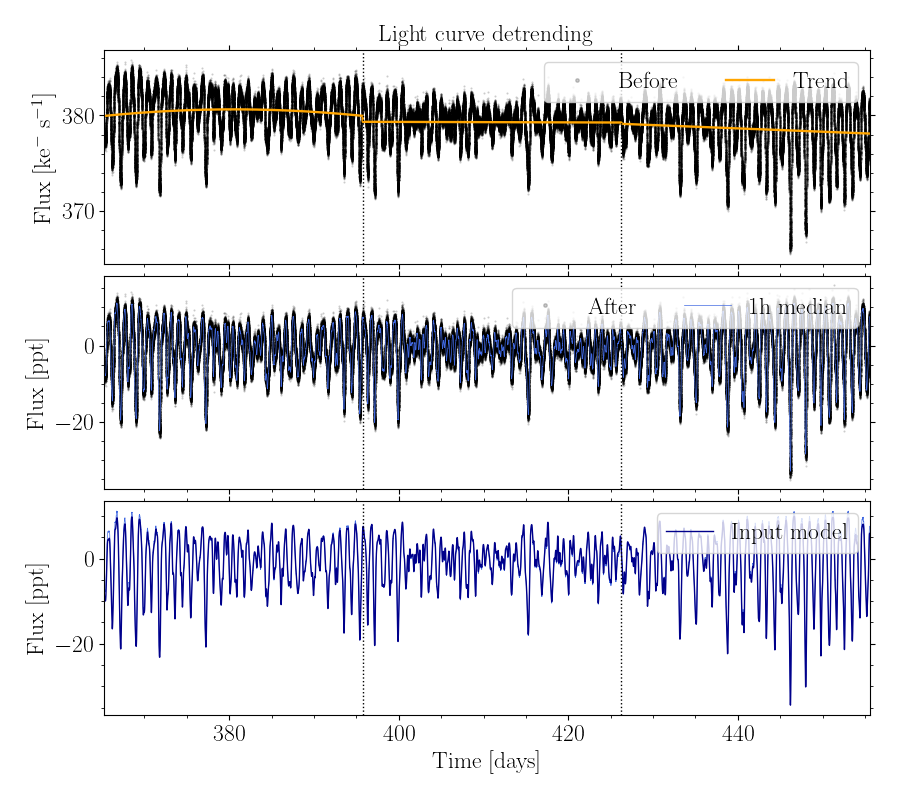

In [18]:
df = lc.detrend(model='poly', replace=True, plot=True)

<IPython.core.display.Javascript object>


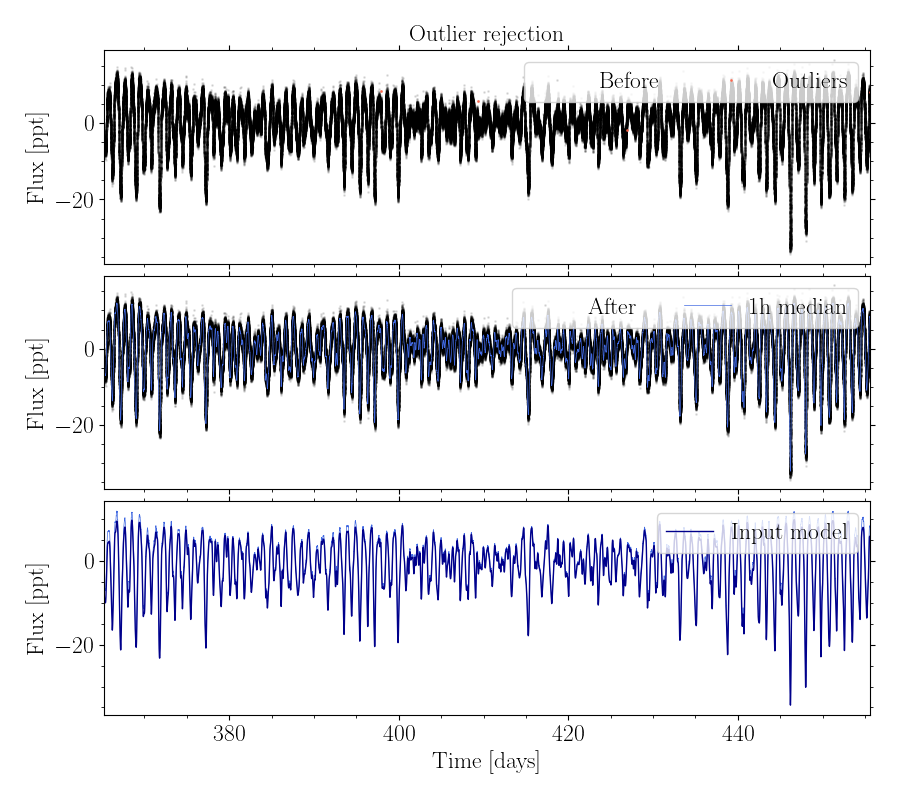

In [19]:
df = lc.clip(model='wotan', flux_unit='ppt', sigma_lower=5, sigma_upper=5, replace=True, plot=True)

In [161]:
# lc.stitch(method='lowess', segment=30, replace=True, plot=True);

In [6]:
# sim = Simulation('test.hdf5') 
# beginExposureNr = int(315569*(int(filename[-6])-1))
# numExposures    = 312113

# # Transient correction
# inputFileCCD = f'{idir}/instrumentGTT.txt'
# dt = pd.read_csv(inputFileCCD, sep=' ', names=['time', 'temp'])
# dt = dt.iloc[beginExposureNr:beginExposureNr+numExposures]
# temp = dt.temp.to_numpy()
# inputFileGap = f'{idir}/instrumentGAP.tab'
# dg = pd.read_feather(inputFileGap)
# tdur = dg.td.iloc[0] / 86400
# tempNominal   = sim['CCD/NominalOperatingTemperature']
# gainCCD       = sim['CCD/Gain/RefValueRight']
# gainFEE       = sim['FEE/Gain/RefValueRight']
# gainStability = sim['FEE/Gain/Stability']
# df = lc.correct_gain(temp, tdur, tempNominal, gainCCD, gainFEE, gainStability, replace=True, plot=True)

---
## Test merging of light curves
---

In [4]:
path = '/lhome/nicholas/software/workdir/mocka_affogato/test_vsc'
star = '000000001'
# star = '000004501'
# star = '000004502'

fdir = f'{path}/{star}'
lcs = LightCurve(fdir, 'multi')

In [69]:
lcs.unpack()

In [70]:
df = lcs.stat_sim_table(ofile=f'{fdir}/lc_{star}.tab', clean=True)
df.head()

Creating simulation table:
[Warning]: Remove your "ofile" to use "clean" (if ".table" files still exists)


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,5303370405309247872,133.456062,-58.724099,13.936833,1,1,1,2,1978.731278,1154.424860,16.197905,-61.700353,-36.917163,4,0.225526
1,1,5303370405309247872,133.456062,-58.724099,13.936833,1,1,5,2,1978.810204,1154.518536,16.197752,-61.698666,-36.918584,4,0.230955
2,1,5303370405309247872,133.456062,-58.724099,13.936833,1,2,1,2,1965.086644,1167.098593,16.129187,-61.472225,-36.671560,4,0.234495
3,1,5303370405309247872,133.456062,-58.724099,13.936833,1,2,5,2,1965.165534,1167.192213,16.129033,-61.470540,-36.672980,4,0.252066
4,1,5303370405309247872,133.456062,-58.724099,13.936833,1,3,1,2,1974.073655,1155.038474,16.186699,-61.689307,-36.833326,4,0.238836


<IPython.core.display.Javascript object>


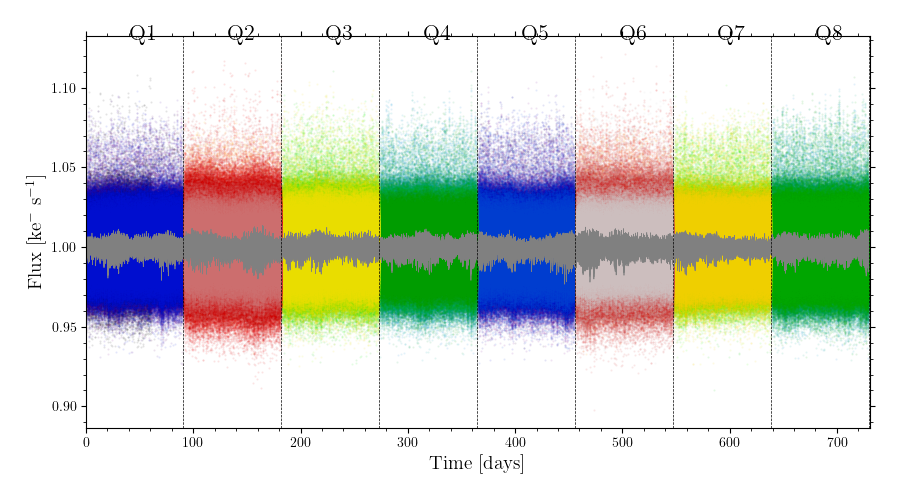

In [71]:
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=1, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

In [72]:
lc = lcs.merge(suffix='ftr', binsize=0.2, flux_group_mean=True, flux_offset=False, 
               ofile=f'{fdir}/lc_final_000000001.ftr')

Merging light curves:


100%|██████████████████████████████████████████████████| 48/48 [00:02<00:00, 17.


Sorting data after timings
Averaging data from same camera group
Binning data per 0.2h
Done!


<IPython.core.display.Javascript object>


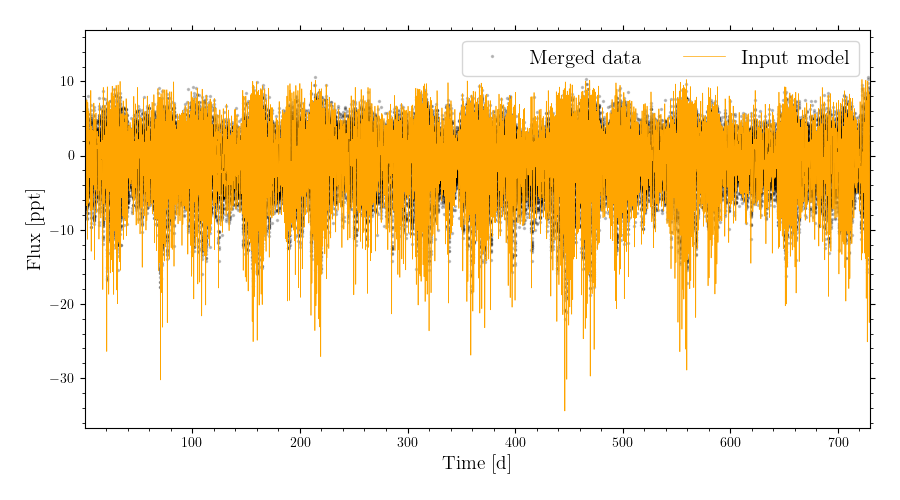

In [73]:
fig, ax = lc.plot(input_model=True, flux_unit='ppt', figsize=(9,5));

---
## Optimal SNR to extract modes
---

In [5]:
path = '/lhome/nicholas/software/workdir/mocka/snr'

### Single cadence

In [17]:
# dx = ut.plotNoisePeakSNR(cadence=600, quarters=1, N=1000, odir=path)

<IPython.core.display.Javascript object>


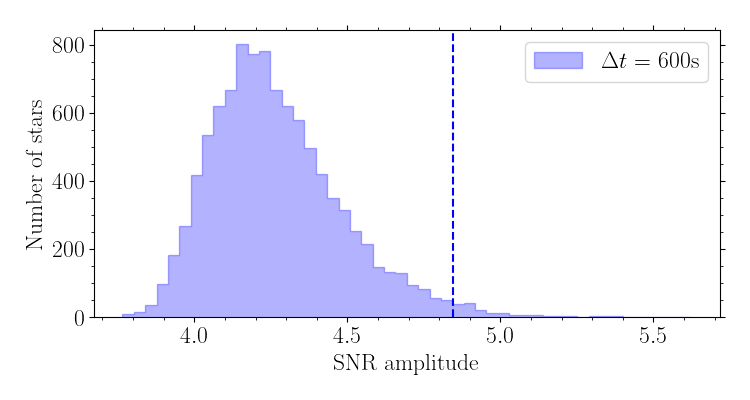

4.845934564977321


In [6]:
fig, ax = ns.plotNoisePeakSNR(path, cadence=600, quarters=8, fap=2, bins=50, figsize=(7.5, 4))

<IPython.core.display.Javascript object>


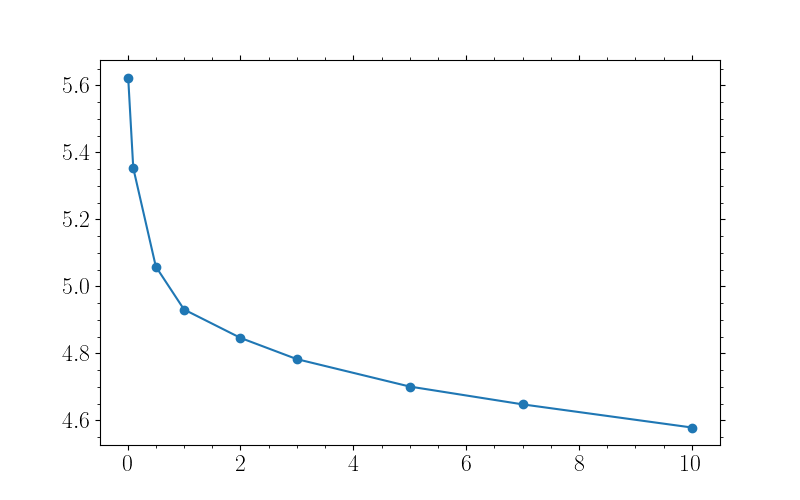

In [7]:
fap = [10, 7, 5, 3, 2, 1, 0.5, 0.1, 0.01]
snr = [4.578423939431306, 4.647514292374852, 4.700650807571664, 4.782483053334303, 4.845934564977321, 4.930671117328056, 5.058795194016849, 5.353100528447329, 5.623227221802466]

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(fap, snr, 'o-');
# ax.set_xscale('log')

### Multiple cadences

In [28]:
# dx = ns.getNoisePeakSNR(path, quarters=1, N=10)

<IPython.core.display.Javascript object>


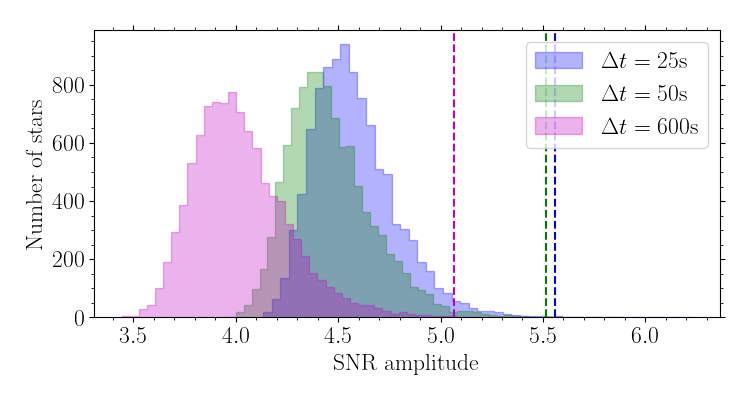

[5.561262525313896, 5.513900092145581, 5.065548026369663]


In [8]:
fig, ax = ns.plotMultiCadenceNoisePeakSNR(path, fap=0.1, quarters=2, bins=50, show_snr=True, figsize=(7.5, 4));
# ax.set_xlim(3.0, 5.6)
# fig.savefig(f'{fdir}/OptimalCriterionSNR.png', bbox_inches='tight', dpi=300)

<IPython.core.display.Javascript object>


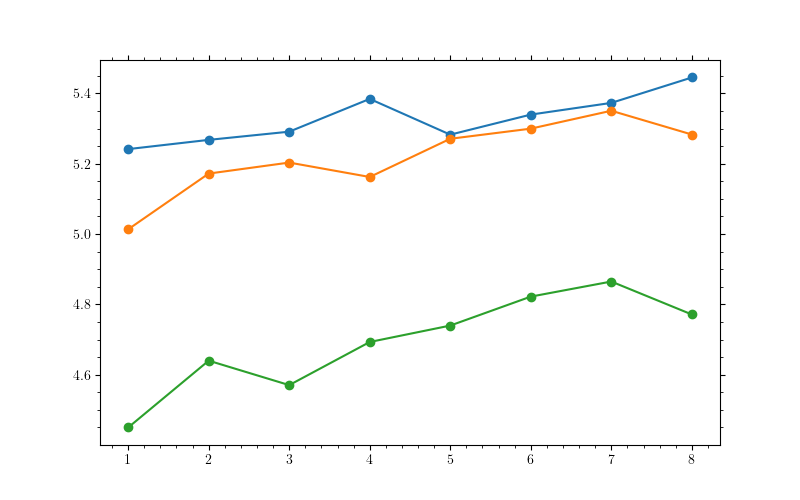

In [112]:
q1 = [5.099032363235153, 5.06139030759917, 4.469069906810321]
q2 = [5.198279088967152, 5.118046230099662, 4.584393387223682]
#------------ 1000 data points
# q1 = [5.241575739765578, 5.01346587885793, 4.449836346061709]
# q2 = [5.267823567265683, 5.17198177171664, 4.639902283276065]
# q3 = [5.291145796982384, 5.20328034705348, 4.570385534548011]
# q4 = [5.384359572567326, 5.1622880738317525, 4.6930150618706135]
# q5 = [5.2826676019222605, 5.270969956010273, 4.739728419194719]
# q6 = [5.339730640464162, 5.299750399560476, 4.822074356620032]
# q7 = [5.37300919704369, 5.350677095584161, 4.864966085814097]
# q8 = [5.445222654734345, 5.283066646614134, 4.7713018478944464]
#------------
snr = np.array([q1, q2, q3, q4, q5, q6, q7, q8])
quarter = np.arange(1, 9, 1)

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(quarter, snr[:,0], 'o-')
ax.plot(quarter, snr[:,1], 'o-')
ax.plot(quarter, snr[:,2], 'o-')

<IPython.core.display.Javascript object>


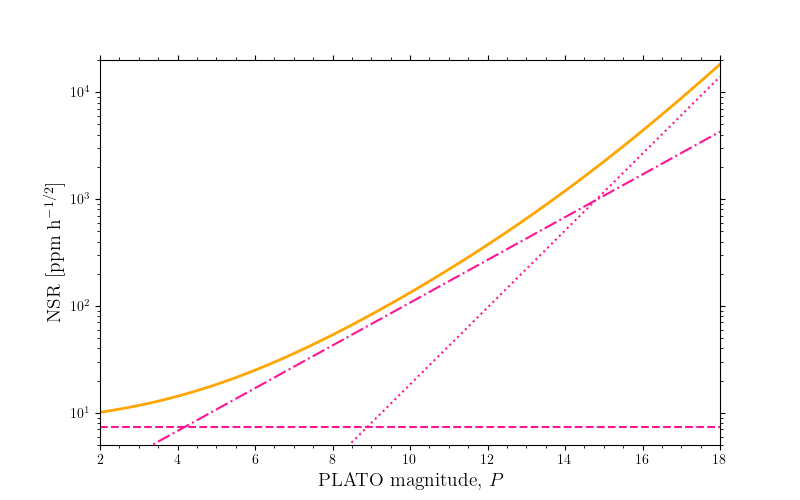

array([  53.61262166,   83.11720526,  133.07389168,  219.56939263,
        373.42350326,  655.67905879, 1191.0235772 , 2241.08291987,
       4367.14334158, 8794.71004336])

In [118]:
mag = np.linspace(2, 18, 100)
noise_jitter     = ut.getJitterNoiseLimitNSR(rms=0.037, level='camera')
noise_photon     = ut.getPhotonNoiseLimitNSR(mag, passband='P', ncam=1)
noise_background = ut.getBackgroundNoiseLimitNSR(mag, passband='P')
noise = noise_jitter + noise_photon + noise_background

fig, ax = plt.subplots(1,1,figsize=(8,5))
ax.plot(mag, noise, '-', c='orange', lw=2,  zorder=2)
ax.plot(mag, noise_background, ':', c='deeppink', lw=1.5, zorder=2)
ax.plot(mag, noise_photon, '-.', c='deeppink', lw=1.5)
ax.axhline(y=noise_jitter, c="deeppink", ls="--", lw=1.5, zorder=2)
ax.set_yscale('log')
ax.set_xlabel(r'PLATO magnitude, $P$')
ax.set_ylabel(r'NSR [ppm h$^{-1/2}$]')
ax.set_xlim(mag[0], mag[-1])
ax.set_ylim(5, 20000);

# Print NSR for a few magnitudes
mag = np.arange(8, 18, 1)
noise_jitter     = ut.getJitterNoiseLimitNSR(rms=0.037, level='camera')
noise_photon     = ut.getPhotonNoiseLimitNSR(mag, passband='P', ncam=1)
noise_background = ut.getBackgroundNoiseLimitNSR(mag, passband='P')
noise = noise_jitter + noise_photon + noise_background
noise

---
## Test frequency extraction with STARSHADOW
---

With a PLATOnium conda environment activated, first install software using
```
pip install git+https://github.com/LucIJspeert/star_shadow
```
Open the file needed to compile the `numba` code
```
$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
Replace the line:
```
data_dir = script_dir.replace('star_shadow', 'data') 
```
with 
```
data_dir = os.path.join(script_dir, 'data')
```
Check that the `data` folder exists within the directory `$CONDA_PREFIX/lib/python3.9/site-packages/star_shadow`. If not, create this directory and download and place the two files `sim_000_lc.dat` and `mpl_stylesheet.dat` into this folder.

Compile the code with:
```
python $CONDA_PREFIX/lib/python3.9/site-packages/star_shadow/run_first_use.py
```
We further implement a small piece of code that records which modes are abvoe a certain SNR during the prewhitening procedure. Then we can compare this to the default procedure of STAR SHADOW.

Now the code can be used.

In [179]:
# import star_shadow as ss
# path = '/lhome/nicholas/software/workdir/mocka/test_vsc'
# filename = f'{path}/varsource/000000001/varsource_001.txt'
# df = pd.read_csv(filename, sep=' ', names=['time', 'mag'])

In [45]:
# df.time /= 86400.
# df['flux'] = ut.fromMagToFlux(df.mag)
# df.flux = (df.flux - df.flux.mean())
# df['flux_err'] = np.ones_like(df.flux)
# df = df.drop(columns=['mag'])
# df = df.loc[::24]  # 600s / 25s-> 24 exp
# df.to_csv(f'{path}/varsource_600s.dat', sep=' ', index=False, header=False)

In [44]:
# plt.figure(figsize=(9,5))
# plt.plot(df.time, df.flux, ',', alpha=0.5);

In [5]:
# ss.analyse_lc_from_file(f'{path}/varsource_600s.dat', save_dir=path, stage='freq', overwrite=True, verbose=True)

---
## Compare input and output
---

In [7]:
# Load star results
star = f'{1}'.zfill(9)
path = '/lhome/nicholas/software/workdir/mocka'
dp = pd.read_feather(f'{path}/test_vsc/varsource/{star}/varsource_001_parameters.ftr')
df = pd.read_feather(f'{path}/test_vsc/varsource/{star}/varsource_001_pulsations.ftr')
dm = pd.read_feather(f'{path}/test_vsc/finals_affogato/modes/modes_{star}.ftr')

# Correct for gamma factor
dm.ampl /= 2.2

# Convert dmag to ppm
df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6

# Fetch input frequencies in pettern
f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day for i in range(dp.N_modes[0])])

# Get pattern
dex_df = np.array([ut.findNearestIndex(df.freq, f_i[i]) for i in range(dp.N_modes[0])])
dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
df0 = df.loc[dex_df].reset_index(drop=True)
dm0 = dm.loc[dex_dm].reset_index(drop=True)

# O-C plot
f_oc = dm0.freq.to_numpy() - df0.freq.to_numpy()
A_oc = dm0.ampl.to_numpy() - df0.ampl.to_numpy()

# Remove matches above 0.01 c/d in the OC diagram
x = 0.0005
dex = np.where((np.abs(f_oc) > x))[0]
dm0 = dm0.drop(index=dex)
f0_oc = np.delete(f_oc, dex)
A0_oc = np.delete(A_oc, dex)

print(f'Stellar magnitude  : {dp.Pmag[0]:.4f} mag')
print(f'Limiting amplitude : {dm.ampl.min():.4f} ppm')
print(f'Number of modes    : {dm0.shape[0]}/{dp.N_modes[0]}')
print(f'RMS O-C amplitude  : {ut.rootMeanSquare(A0_oc):.4f} ppm')
print(f'RMS O-C frequency  : {ut.rootMeanSquare(f0_oc)*1e6:.4f} ppm/d')

FileNotFoundError: [Errno 2] No such file or directory: '/lhome/nicholas/software/workdir/mocka/test_vsc/varsource/000000001/varsource_001_parameters.ftr'

<IPython.core.display.Javascript object>


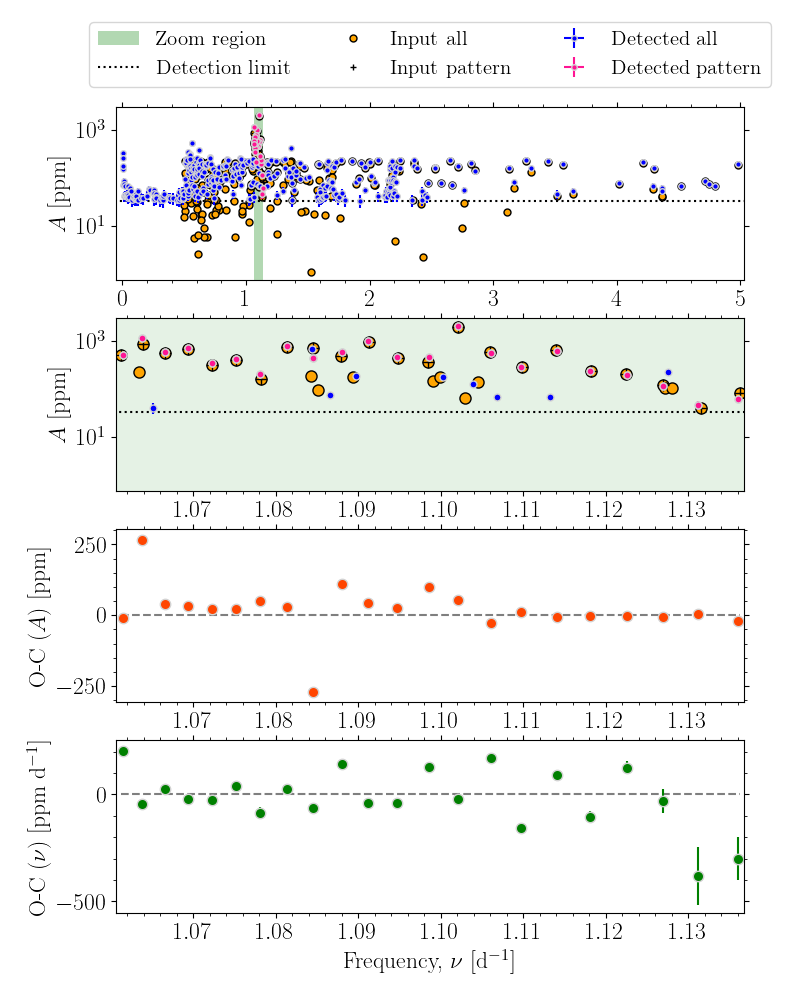

In [13]:
fig, ax = plt.subplots(4, 1, figsize=(8,10))

xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_yscale('log')
ax[1].set_xlim(xlim1[1], xlim1[0])

ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[2].errorbar(dm0.freq, A0_oc, xerr=None, yerr=dm0.ampl_err, fmt=".", ms=15, mec='lightgray', color="orangered")
ax[2].set_ylabel(r'O-C ($A$) [ppm]')
ax[2].set_xlim(xlim1[1], xlim1[0])

ax[3].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
ax[3].errorbar(dm0.freq, f0_oc*1e6, xerr=None, yerr=dm0.freq_err*1e6, fmt=".", ms=15, mec='lightgray', color="g")
ax[3].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[3].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[3].set_xlim(xlim1[1], xlim1[0])

plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

In [46]:
# fig, ax = plt.subplots(3, 1, figsize=(8,8))

# xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
# xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

# ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
# ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
# ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
# ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
# ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
# ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
# ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
# ax[0].set_ylabel(r'$A$ [ppm]')
# ax[0].set_yscale('log')
# ax[0].set_xlim(xlim0)

# ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
# ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
# ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
# ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
# ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
# ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
# ax[1].set_ylabel(r'$A$ [ppm]')
# ax[1].set_yscale('log')
# ax[1].set_xlim(xlim1[1], xlim1[0])

# ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
# ax[2].errorbar(dm0.freq, f0_oc*1e4, xerr=None, yerr=dm0.freq_err*1e4, fmt=".", ms=15, mec='lightgray', color="g")
# ax[2].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
# ax[2].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
# ax[2].set_xlim(xlim1[1], xlim1[0])

# plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)